In [1]:
import geopandas as df
import matplotlib.pyplot as plt

In [2]:
fname = "erosion_de_99_cuencas_WGS84.geojsonl.json"

In [3]:
df = df.read_file(fname)

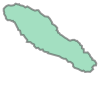

In [4]:
df["geometry"][4]

In [10]:
df.head()

,NOMBRE,A_pon_cuen,Cluster,geometry
0,Olimar Grande,1.069,3,"MULTIPOLYGON (((-54.36486 -33.2924, -54.36301 ..."
1,A_San Miguel,0.785,3,"MULTIPOLYGON (((-53.94668 -34.03117, -53.94936..."
2,A_Guaviyu,3.365,1,"MULTIPOLYGON (((-57.94336 -31.92985, -57.9343 ..."
3,A_San Antonio,5.534,1,"MULTIPOLYGON (((-57.85644 -31.37341, -57.84574..."
4,None,3.154,1,"MULTIPOLYGON (((-57.80816 -33.20883, -57.80679..."


In [5]:
df["Cluster"].unique()

array([3, 1, 2, 4], dtype=int32)

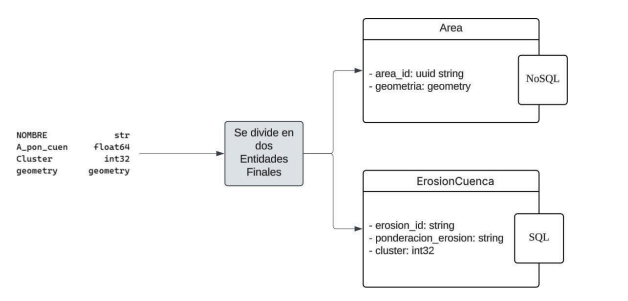

In [6]:
df.isnull().sum()

NOMBRE        4
A_pon_cuen    0
Cluster       0
geometry      0
dtype: int64

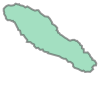

In [7]:
df[df["NOMBRE"].isnull()]["geometry"][4]

In [8]:
df[df["NOMBRE"].notnull()].shape

(95, 4)

In [11]:
df.head()

,NOMBRE,A_pon_cuen,Cluster,geometry
0,Olimar Grande,1.069,3,"MULTIPOLYGON (((-54.36486 -33.2924, -54.36301 ..."
1,A_San Miguel,0.785,3,"MULTIPOLYGON (((-53.94668 -34.03117, -53.94936..."
2,A_Guaviyu,3.365,1,"MULTIPOLYGON (((-57.94336 -31.92985, -57.9343 ..."
3,A_San Antonio,5.534,1,"MULTIPOLYGON (((-57.85644 -31.37341, -57.84574..."
4,None,3.154,1,"MULTIPOLYGON (((-57.80816 -33.20883, -57.80679..."


In [12]:
print(df.geometry[0]) # 
#df.geometry[0]

MULTIPOLYGON (((-54.3648594 -33.2924015, -54.3630106 -33.2928546, -54.3579465 -33.2940955, -54.3508116 -33.2958435, -54.3431326 -33.2986912, -54.3429908 -33.2987168, -54.3012193 -33.3062276, -54.260591 -33.3135181, -54.240743 -33.3106624, -54.2320666 -33.309413, -54.2184481 -33.3074506, -54.2121846 -33.3065476, -54.2063514 -33.3057062, -54.1742348 -33.3010689, -54.1543746 -33.299773, -54.1383459 -33.2987248, -54.1290042 -33.2992293, -54.0670421 -33.3025572, -54.0424555 -33.299675, -54.0353727 -33.3003143, -54.0303097 -33.300771, -54.0227926 -33.2970546, -54.0205226 -33.2959322, -54.0174658 -33.2944206, -54.0157108 -33.2935527, -54.013283 -33.2893899, -54.0051902 -33.2755103, -53.9851497 -33.2705663, -53.9798885 -33.2692678, -53.975598 -33.262414, -53.9746586 -33.2609133, -53.9731533 -33.2568858, -53.9687052 -33.2568203, -53.9509686 -33.2647448, -53.9325019 -33.2729913, -53.9305212 -33.2738755, -53.9222294 -33.2759209, -53.9161541 -33.277419, -53.907076 -33.279657, -53.9039958 -33.28041

Text(0.5, 1.0, 'Poligonos de cada Cuenca')

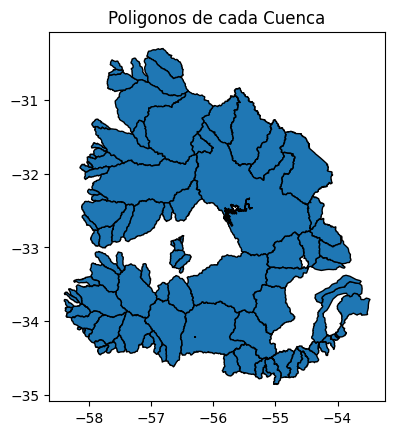

In [13]:
df.plot(edgecolor="black")
plt.title("Poligonos de cada Cuenca")

In [14]:
# Se repiten los nombres?
nombres_count = {}
for n in df["NOMBRE"]:
    nombres_count[n] = nombres_count.get(n, 0) + 1

nombres_repetidos = set([kv[0] for kv in nombres_count.items() if kv[1] > 1])
nombres_repetidos

{'A_Grande',
 'A_Parao',
 'A_Rocha',
 'A_Sauce',
 None,
 'Olimar Grande',
 'Rio Negro',
 'Rio Santa Lucia'}

In [15]:
df[df["NOMBRE"] == "Olimar Grande"]

,NOMBRE,A_pon_cuen,Cluster,geometry
0,Olimar Grande,1.069,3,"MULTIPOLYGON (((-54.36486 -33.2924, -54.36301 ..."
54,Olimar Grande,3.217,2,"MULTIPOLYGON (((-55.11197 -33.25361, -55.10866..."
71,Olimar Grande,3.552,2,"MULTIPOLYGON (((-54.53544 -33.13845, -54.53483..."


In [16]:
df[df["NOMBRE"] == "A_Rocha"]

,NOMBRE,A_pon_cuen,Cluster,geometry
19,A_Rocha,2.009,2,"MULTIPOLYGON (((-54.40299 -34.42038, -54.40186..."
23,A_Rocha,2.060,2,"MULTIPOLYGON (((-54.58861 -34.41815, -54.58432..."


### Mismo nombre pero las geometrias son diferentes :)

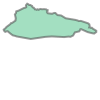

In [17]:
df.geometry[0]


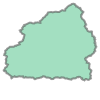

In [18]:
df.geometry[54]

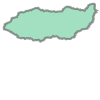

In [19]:
df.geometry[72]

In [20]:
{
  "nombre": "Cuenca X",
  "tipo_area": "cuenca",
  "geometry": {
    "type": "MultiPolygon",
    "coordinates": [...]
  }
}

{'nombre': 'Cuenca X',
 'tipo_area': 'cuenca',
 'geometry': {'type': 'MultiPolygon', 'coordinates': [Ellipsis]}}

In [ ]:
from pymongo import UpdateOne
from shapely.geometry import mapping

operations = []

for _, row in gdf.iterrows():
    area_id = str(row["NOMBRE"]).lower().replace(" ", "_")

    doc = {
        "_id": area_id,
        "nombre": row["NOMBRE"],
        "tipo_area": "cuenca",
        "geometry": mapping(row["geometry"])
    }

    operations.append(
        UpdateOne(
            {"_id": area_id},
            {"$set": doc},
            upsert=True
        )
    )

db.areas.bulk_write(operations)

In [64]:
#import psycopg ## Libreria de python para establecer una conexio directa con PostgreSQL.
#import os
#from psycopg import Connection
#
#from pymongo import MongoClient
#from pymongo.database import Database
#
#DATABASE_URL = 
#MONGO_URL = 
#
#def get_postgres_conn() -> Connection:
#    return psycopg.connect(DATABASE_URL)
#
#def get_mongo_conn() -> Database:
#    client = MongoClient(MONGO_URL)
#    return client

### 

In [24]:
#for n in list(df["NOMBRE"]):

In [25]:
df.head()

,NOMBRE,A_pon_cuen,Cluster,geometry
0,Olimar Grande,1.069,3,"MULTIPOLYGON (((-54.36486 -33.2924, -54.36301 ..."
1,A_San Miguel,0.785,3,"MULTIPOLYGON (((-53.94668 -34.03117, -53.94936..."
2,A_Guaviyu,3.365,1,"MULTIPOLYGON (((-57.94336 -31.92985, -57.9343 ..."
3,A_San Antonio,5.534,1,"MULTIPOLYGON (((-57.85644 -31.37341, -57.84574..."
4,None,3.154,1,"MULTIPOLYGON (((-57.80816 -33.20883, -57.80679..."


In [ ]:
# si se repite -> agregaamos un contador al final
# si es none -> le ponemos un id AreaA, AreaB, etc...

In [30]:
for n in df["NOMBRE"]:
    nombre_fixed = fix_nombre(n)
#    df["NOMBRE"
gdf["NOMBRE"] = gdf["NOMBRE"].replace("Nombre viejo", "Nombre nuevo")

In [39]:
df["NOMBRE"]

0     Olimar Grande
1      A_San Miguel
2         A_Guaviyu
3     A_San Antonio
4              None
          ...      
94        A_Tacuari
95        A_De Vera
96          A_Parao
97        A_Rosario
98         A_Grande
Name: NOMBRE, Length: 99, dtype: object

In [41]:
df[df["NOMBRE"] == "Olimar Grande"]

,NOMBRE,A_pon_cuen,Cluster,geometry
0,Olimar Grande,1.069,3,"MULTIPOLYGON (((-54.36486 -33.2924, -54.36301 ..."
54,Olimar Grande,3.217,2,"MULTIPOLYGON (((-55.11197 -33.25361, -55.10866..."
71,Olimar Grande,3.552,2,"MULTIPOLYGON (((-54.53544 -33.13845, -54.53483..."


In [52]:
df[df["NOMBRE"] == "Olimar Grande"].index

Index([0, 54, 71], dtype='int64')

In [55]:
nombres_repetidos

{'A_Grande',
 'A_Parao',
 'A_Rocha',
 'A_Sauce',
 None,
 'Olimar Grande',
 'Rio Negro',
 'Rio Santa Lucia'}

In [59]:
    
counts

{'A_Grande': 0,
 'A_Sauce': 0,
 'Olimar Grande': 0,
 'Rio Negro': 0,
 'A_Rocha': 0,
 'Rio Santa Lucia': 0,
 'A_Parao': 0}

In [64]:

def fix_nombres(df) -> str:
    nuevos_nombres = []
    areas_disponibles = set(["AREA_A", "AREA_B", "AREA_C", "AREA_D"])
    counts = {}
    for nombre in nombres_repetidos:
        if nombre != None:
            counts[nombre] = 0

    def fix_repetido(n):
        i = counts[n]
        res = f"{n}_{i+1}"
        counts[n] += 1
        return res
        
    for n in df["NOMBRE"]:
        if n != None and n in nombres_repetidos:
            nuevo = fix_repetido(n)
            nuevos_nombres.append(nuevo)
        elif n == None:
            nuevo = areas_disponibles.pop()
            nuevos_nombres.append(nuevo)
        else:
            nuevos_nombres.append(n)

    return nuevos_nombres



    
# recorrer todos los nombres
# si el nombre esta en repetidos # nombre_i, nombre_1, nombre_2, nombre_3 ....
# arreglar_repetido
# si no esta repetido
# esta ok o es none, si es none -> Le asignamos uno
# si esta ok, no hacemos nada

In [73]:
new_names = fix_nombres(df)
for n in new_names:
    print(n)
#print(list(res))


Olimar Grande_1
A_San Miguel
A_Guaviyu
A_San Antonio
AREA_B
Rio Dayman
AREA_D
A_Don Carlos
A_Yacui
A_Yucutuja
AREA_A
A_Las viboras
A_Sauce_1
A_de la agraciada
A_San Fco_grande
A_Cufre
A_Parao_1
A_Grande_1
A_Maciel
A_Rocha_1
Tacuarembo chico
A_Del chafalote
A_Jose Ignacio
A_Rocha_2
A_San Carlos
A_Coladera
A_Garzon
A_San Luis
A_Del Sauce
A_Don Esteban
A_Maldonado
A_Sanchez
A_Solis grande
A_Santo Domingo
A_Pan de azucar
A_de pelotas
Rio Santa Lucia_1
A_Vazquez
Tacuarembo grande
A_Solis Chico
San Jose
Rio Negro_1
A_Pavon
AREA_C
A_Luis Pereira
A_Juan Esteban
A_De Caballero
Rio Tacuarembo
A_de Villasboas
A_Salsipuedes grande
A_Porongos
Yaguari
Rio Cebollati
Rio Negro_2
Olimar Grande_2
Rio Santa Lucia_2
A_Sarandi_d_China
A_Marincho
A_del Tala
A_Sarandi del Yi
A_San Juan
A_Sauce_2
A_de las Limetas
A_Conchillas
A_San Pedro
A_Riachuelo
A_de la caballada
A_bequelo
A_Sauce_3
A_La vacas
Yi
Olimar Grande_3
Queguay
A_Tres Arboles
A_San Fco_chico
Rio Olimar
A_San Pedro Grande
A_Quebracho Grande
A_Chap

In [74]:
def cambiar_nombres(gdf, nombres_nuevos):
    if len(gdf) != len(nombres_nuevos):
        raise ValueError("La cantidad de nombres nuevos no coincide con la cantidad de filas del GeoDataFrame")

    gdf = gdf.copy()
    gdf["NOMBRE"] = nombres_nuevos

    return gdf


cambiar_nombres(df, new_names)


,NOMBRE,A_pon_cuen,Cluster,geometry
0,Olimar Grande_1,1.069,3,"MULTIPOLYGON (((-54.36486 -33.2924, -54.36301 ..."
1,A_San Miguel,0.785,3,"MULTIPOLYGON (((-53.94668 -34.03117, -53.94936..."
2,A_Guaviyu,3.365,1,"MULTIPOLYGON (((-57.94336 -31.92985, -57.9343 ..."
3,A_San Antonio,5.534,1,"MULTIPOLYGON (((-57.85644 -31.37341, -57.84574..."
4,AREA_B,3.154,1,"MULTIPOLYGON (((-57.80816 -33.20883, -57.80679..."
...,...,...,...,...
94,A_Tacuari,3.139,3,"MULTIPOLYGON (((-54.44618 -32.74359, -54.44381..."
95,A_De Vera,3.167,1,"MULTIPOLYGON (((-57.54576 -33.26093, -57.5376 ..."
96,A_Parao_2,1.172,3,"MULTIPOLYGON (((-54.1557 -33.1657, -54.13696 -..."
97,A_Rosario,6.132,1,"MULTIPOLYGON (((-57.42939 -34.30251, -57.42326..."


In [82]:
for _, item in df.iterrows():
    nombre = item["NOMBRE"]
    cluster = item["Cluster"]
    pon = item["A_pon_cuen"]
    geometry = item["geometry"]

    # read only
    if hash_existe():
        pass

    insert_mongo() # hash

    insert_sql()
    
    
    print(nombre, pon)
    break
#nombre = df["NOMBRE"]

Olimar Grande 1.069


In [83]:
def hash(secret_message: str):
    import hashlib
    message_bytes = secret_message.encode('utf-8')
    hash_object = hashlib.sha256(message_bytes)
    hex_dig = hash_object.hexdigest()
    return hex_dig

In [84]:
hash("hola")

'b221d9dbb083a7f33428d7c2a3c3198ae925614d70210e28716ccaa7cd4ddb79'

In [85]:
hash("holx")

'82458db861a3bf6eaf2c641652095ba757c536352c925844930852885daefb91'

In [86]:
hash("hola")

'b221d9dbb083a7f33428d7c2a3c3198ae925614d70210e28716ccaa7cd4ddb79'